# Steam Games — Data Cleaning & Processing
**DATA 230 Group Project · Section owner: Keerat**

**Research question:** *Can a classifier predict a Steam game's commercial success from features known **before release**, and which features matter most?*

That question drives every cleaning decision below:
1. We need a trustworthy **outcome** (how successful did the game become?).
2. We need **pre-release features** (price, genres, platforms, languages…), kept separate from post-release numbers (reviews, playtime, players) so the model doesn't "cheat" (data leakage).
3. We should only keep rows that are **real, released games** with enough history to have had a chance to sell.

| Step | What it does |
|---|---|
| 0 | Load the data |
| 1 | Fix the shifted-header bug in `games.csv` |
| 2 | Profile the raw data (size, types, real *and disguised* missing values) |
| 3 | Convert types (dates, owner ranges, list-columns) |
| 4 | Filter rows (duplicates, unreleased/no-data, non-games, too-recent) |
| 5 | Drop columns that don't help (URLs, images, ~empty columns) |
| 6 | Handle missing values & outliers |
| 7 | Engineer features (pre-release) and candidate success targets (outcomes) |
| 8 | Visualize before/after cleaning (for slides) |
| 9 | Export clean files for EDA (Rachel), ML (Chinmayi) and Tableau (Calvin) |

In [7]:
# ---- Step 0: Load ----------------------------------------------------------
import os, ast, csv, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

# In Colab: download with kagglehub. If you're running elsewhere, set CSV_PATH by hand.
CSV_PATH = os.environ.get("STEAM_CSV")
if CSV_PATH is None:
    import kagglehub
    path = kagglehub.dataset_download("fronkongames/steam-games-dataset")
    CSV_PATH = os.path.join(path, "games.csv")
print("Reading:", CSV_PATH)

OUT_DIR = "clean_output"          # all exported files go here
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# Chart styling (consistent across all cleaning figures)
BEFORE, AFTER, ACCENT, MUTED, INK = "#898781", "#2a78d6", "#eb6834", "#898781", "#0b0b0b"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
})

Using Colab cache for faster access to the 'steam-games-dataset' dataset.
Reading: /kaggle/input/steam-games-dataset/games.csv


## Step 1 — The shifted-header bug (our first big cleaning challenge)
The header row of `games.csv` has **39** names, but every data row has **40** values.
The culprit is one header cell, `DiscountDLC count`: it should be **two** columns, `Discount` and `DLC count` (a missing comma upstream).

If you just call `pd.read_csv()`, pandas silently mislabels columns — e.g. the column called *Price* actually holds the discount %, and *Name* holds the release date (exactly what happens depends on your pandas version). Nothing errors out, so it's easy to miss. **Every analysis built on the naive load would be wrong.**

Fix: read the real header, split the merged name in two, and pass the corrected names to `read_csv`.

In [9]:
# What the naive load looks like (BROKEN) — keep this for the slide
naive = pd.read_csv(CSV_PATH, nrows=3)
print("Naive load: ", naive.shape[1], "columns")
display(naive.iloc[:3, :10])

with open(CSV_PATH, newline="", encoding="utf-8") as f:
    header = next(csv.reader(f))
with open(CSV_PATH, newline="", encoding="utf-8") as f:
    reader = csv.reader(f); next(reader); first_row = next(reader)
print(f"\nHeader has {len(header)} names, first data row has {len(first_row)} values")

fixed_cols = []
for c in header:
    fixed_cols += ["Discount", "DLC count"] if c == "DiscountDLC count" else [c]

# header=None + skiprows=1: use OUR names; rows with a trailing empty field are padded with NaN
raw = pd.read_csv(CSV_PATH, header=None, skiprows=1, names=fixed_cols, index_col=False, low_memory=False)
print("Fixed load:", raw.shape)

# Sanity checks: if the columns line up, these must all hold
assert raw["Discount"].between(0, 100).all(), "Discount should be a % in 0-100"
assert pd.api.types.is_numeric_dtype(raw["Price"]), "Price should be numeric"
assert raw["Estimated owners"].astype(str).str.contains(" - ").all(), "Owners should look like '0 - 20000'"
assert raw["Windows"].astype(str).str.lower().isin(["true", "false"]).all(), "Windows should be boolean"
print("✓ Column alignment verified")
raw[["AppID", "Name", "Release date", "Estimated owners", "Price", "Discount", "DLC count"]].head()

Naive load:  39 columns


,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[]
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English']
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']"



Header has 39 names, first data row has 40 values
Fixed load: (125855, 40)
✓ Column alignment verified


,AppID,Name,Release date,Estimated owners,Price,Discount,DLC count
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0.00,0,0
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,5.24,65,0
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,4.99,0,0
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,8.99,0,1
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,4.99,0,0


## Step 2 — Profile the raw data
Missing values in this dataset come in **two forms**:
* **Real missing** (`NaN`): e.g. `Score rank`, `Reviews`, `Website`.
* **Disguised missing**: placeholders that *look* like data — `0` for Metacritic/User score (0 means "no score", not "scored zero"), `"[]"` for empty language lists, `"0 - 0"` for owners.

Counting only `NaN` would badly understate how incomplete some columns are, so we measure both.

In [10]:
print(f"Raw shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns")
print(raw.dtypes.value_counts().to_string())

def missing_report(df):
    """% of rows that are truly missing (NaN) or 'disguised' missing (placeholder values)."""
    rep = {}
    for c in df.columns:
        s = df[c]
        nan = s.isna()
        disguised = pd.Series(False, index=s.index)
        if s.dtype == object or pd.api.types.is_string_dtype(s):
            disguised = s.astype(str).str.strip().isin(["[]", "", "0 - 0"])
        elif c in ("Metacritic score", "User score", "Median playtime forever", "Average playtime forever"):
            disguised = s.eq(0)
        rep[c] = {"nan_%": nan.mean() * 100, "disguised_%": (disguised & ~nan).mean() * 100}
    rep = pd.DataFrame(rep).T
    rep["total_missing_%"] = rep.sum(axis=1)
    return rep.sort_values("total_missing_%", ascending=False).round(1)

miss_before = missing_report(raw)
miss_before.head(20)

Raw shape: 125,855 rows × 40 columns
object     19
int64      15
float64     3
bool        3


,nan_%,disguised_%,total_missing_%
Movies,100.0,0.0,100.0
User score,0.0,100.0,100.0
Score rank,100.0,0.0,100.0
Metacritic score,0.0,96.6,96.6
Metacritic url,96.6,0.0,96.6
Reviews,90.3,0.0,90.3
Notes,81.5,0.0,81.5
Average playtime forever,0.0,79.2,79.2
Median playtime forever,0.0,79.2,79.2
Website,59.9,0.0,59.9


## Step 3 — Convert types
* **Release date** → real `datetime` (the raw file stores text like `"Aug 1, 2023"`).
* **Estimated owners** → two numbers, `owners_low` and `owners_high` (raw is text like `"20000 - 50000"`). Steam only publishes these *ranges*, not exact sales.
* **List columns** stored as text: languages look like `"['English', 'French']"`; genres/categories/tags/developers look like `"Action,Indie"`. We parse them into real Python lists so we can count and one-hot encode them.
* **Booleans** (`Windows`, `Mac`, `Linux`) → True/False.

In [11]:
df = raw.copy()
df.columns = [c.strip() for c in df.columns]

# Dates
df["release_date"] = pd.to_datetime(df["Release date"], format="mixed", errors="coerce")
print("Unparseable release dates:", df["release_date"].isna().sum())

# Owners range "20000 - 50000" -> numbers
own = df["Estimated owners"].astype(str).str.split(" - ", expand=True)
df["owners_low"] = pd.to_numeric(own[0], errors="coerce")
df["owners_high"] = pd.to_numeric(own[1], errors="coerce")

# List-like columns
def parse_py_list(x):
    """"['English', 'French']" -> ['English', 'French']"""
    if pd.isna(x) or str(x).strip() in ("", "[]"):
        return []
    try:
        v = ast.literal_eval(str(x))
        return [str(i).strip() for i in v] if isinstance(v, (list, tuple)) else []
    except (ValueError, SyntaxError):
        return [p.strip(" '\"[]") for p in str(x).split(",") if p.strip(" '\"[]")]

def parse_csv_list(x):
    """"Action,Indie" -> ['Action', 'Indie']"""
    if pd.isna(x) or str(x).strip() == "":
        return []
    return [p.strip() for p in str(x).split(",") if p.strip()]

for col, new in [("Supported languages", "languages"), ("Full audio languages", "audio_languages")]:
    df[new] = df[col].apply(parse_py_list)
for col, new in [("Genres", "genres"), ("Categories", "categories"), ("Tags", "tags"),
                 ("Developers", "developers"), ("Publishers", "publishers")]:
    df[new] = df[col].apply(parse_csv_list)

# Normalise genre spelling ("Free to Play" vs "Free To Play")
df["genres"] = df["genres"].apply(lambda g: [x.title().replace("Rpg", "RPG") for x in g])

for b in ["Windows", "Mac", "Linux"]:
    df[b] = df[b].astype(str).str.lower().eq("true")

df[["Name", "release_date", "owners_low", "owners_high", "languages", "genres"]].head()

Unparseable release dates: 0


,Name,release_date,owners_low,owners_high,languages,genres
0,Black Dragon Mage Playtest,2023-08-01,0,0,[],[]
1,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0,20000,[English],[Adventure]
2,Mystery Solitaire The Black Raven,2019-05-06,0,20000,"[English, French, German, Russian]",[Casual]
3,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,0,20000,[Korean],"[Casual, Indie, Simulation]"
4,Maze Quest VR,2025-04-24,0,20000,[English],"[Action, Early Access]"


## Step 4 — Filter rows
Every removal is logged so we can show a **row funnel** on the slide. The reasons:

| Filter | Why |
|---|---|
| Duplicate `AppID` | Same game counted twice. |
| No/invalid release date | Can't place the game in time or compute its age. |
| Owners = `"0 - 0"` | Unreleased, playtests, or delisted pages: Steam has **no sales data** for them, so they can't be labelled as success/failure. |
| Software, not a game | The dataset claims "games only", but some apps list only software genres (Utilities, Audio Production, …). They're not relevant to our question. |
| Released too recently | A game released in the last 6 months of the snapshot hasn't had time to sell; labelling it a "failure" would be unfair and add noise. |

In [13]:
funnel = [("Raw dataset", len(df))]
def log_step(label, new_df):
    funnel.append((label, len(new_df)))
    print(f"{label:<40} {funnel[-2][1] - len(new_df):>8,} removed → {len(new_df):>8,} rows")
    return new_df

df = log_step("Drop duplicate AppIDs", df.drop_duplicates(subset="AppID"))
df = log_step("Drop missing release date", df[df["release_date"].notna()])
df = log_step('Drop no sales data (owners "0 - 0")', df[df["owners_high"] > 0])

SOFTWARE_GENRES = {"Utilities", "Design & Illustration", "Animation & Modeling", "Audio Production",
                   "Video Production", "Photo Editing", "Web Publishing", "Education", "Software Training",
                   "Accounting", "Game Development", "Movie", "Documentary", "Episodic", "Short",
                   "Tutorial", "360 Video"}
is_software = df["genres"].apply(lambda g: len(g) > 0 and set(g) <= SOFTWARE_GENRES)
df = log_step("Drop non-game software", df[~is_software])

# Snapshot date = newest release that already has sales data. CHECK the printed value looks sensible.
SNAPSHOT_DATE = df["release_date"].max()
print("\nData snapshot date (newest release with sales data):", SNAPSHOT_DATE.date())
RECENT_CUTOFF = SNAPSHOT_DATE - pd.DateOffset(months=6)
df = log_step("Drop released < 6 months before snapshot", df[df["release_date"] <= RECENT_CUTOFF])

funnel_df = pd.DataFrame(funnel, columns=["step", "rows_remaining"])
funnel_df

Drop duplicate AppIDs                           0 removed →  125,855 rows
Drop missing release date                       0 removed →  125,855 rows
Drop no sales data (owners "0 - 0")        24,579 removed →  101,276 rows
Drop non-game software                      1,099 removed →  100,177 rows

Data snapshot date (newest release with sales data): 2026-03-01
Drop released < 6 months before snapshot    4,390 removed →   95,787 rows


,step,rows_remaining
0,Raw dataset,125855
1,Drop duplicate AppIDs,125855
2,Drop missing release date,125855
3,"Drop no sales data (owners ""0 - 0"")",101276
4,Drop non-game software,100177
5,Drop released < 6 months before snapshot,95787


## Step 5 — Drop columns that don't help
We keep the dataset lean and explain each drop:

In [14]:
DROP_COLS = {
    "Header image": "Image URL, no analytical value",
    "Screenshots": "Image URLs",
    "Movies": "Video URLs",
    "Metacritic url": "URL (Metacritic score kept separately)",
    "Website": "URL → replaced by has_website flag",
    "Support url": "URL → replaced by has_support_url flag",
    "Support email": "Contact info → replaced by has_support_email flag",
    "Score rank": "~100% missing",
    "User score": "~100% zero (disguised missing)",
    "Reviews": "~90% missing press-quote text → has_press_quotes flag",
    "Notes": "Free-text content warnings → has_content_notes flag",
    "Release date": "Replaced by parsed release_date",
    "Estimated owners": "Replaced by owners_low / owners_high",
    "Supported languages": "Replaced by parsed list + counts",
    "Full audio languages": "Replaced by parsed list + counts",
    "Genres": "Replaced by parsed list + one-hot columns",
    "Categories": "Replaced by parsed list + one-hot columns",
    "Tags": "Replaced by parsed list (separate long table)",
    "Developers": "Replaced by parsed list", "Publishers": "Replaced by parsed list",
}
# Create the replacement flags before dropping
df["has_website"] = df["Website"].notna()
df["has_support_url"] = df["Support url"].notna()
df["has_support_email"] = df["Support email"].notna()
df["has_press_quotes"] = df["Reviews"].notna()
df["has_content_notes"] = df["Notes"].notna()

drop_table = pd.DataFrame({"column": list(DROP_COLS), "reason": list(DROP_COLS.values())})
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
print("Columns now:", df.shape[1])
drop_table

Columns now: 35


,column,reason
0,Header image,"Image URL, no analytical value"
1,Screenshots,Image URLs
2,Movies,Video URLs
3,Metacritic url,URL (Metacritic score kept separately)
4,Website,URL → replaced by has_website flag
5,Support url,URL → replaced by has_support_url flag
6,Support email,Contact info → replaced by has_support_email flag
7,Score rank,~100% missing
8,User score,~100% zero (disguised missing)
9,Reviews,~90% missing press-quote text → has_press_quot...


## Step 6 — Missing values & outliers
**Missing values**
* `About the game` empty → empty string (its *length* becomes a feature, 0 is meaningful).
* Empty developer/publisher lists → `"Unknown"`.
* Metacritic score `0` → `NaN` (0 means *not reviewed*). Median/average playtime `0` → `NaN` (SteamSpy didn't track it).

**Outliers** — we *don't* delete real blockbusters (they're the very games we want to learn from). Instead:
* Heavily skewed counts (reviews, owners, players) get a **log transform** (`log1p`) for EDA and modelling.
* Clearly unrealistic values get **capped and flagged**: prices above \$100 (a handful of joke/bundle listings up to \$999) and achievement counts in the thousands (achievement-spam games).

In [15]:
df["About the game"] = df["About the game"].fillna("")
df["developer"] = df["developers"].apply(lambda l: l[0] if l else "Unknown")
df["publisher"] = df["publishers"].apply(lambda l: l[0] if l else "Unknown")

df["metacritic_score"] = df["Metacritic score"].replace(0, np.nan)
for c in ["Average playtime forever", "Median playtime forever"]:
    df[c] = df[c].replace(0, np.nan)

# --- Outliers ---
print("Price > $100:", (df["Price"] > 100).sum())
display(df.loc[df["Price"] > 100, ["Name", "Price", "genres"]].sort_values("Price", ascending=False).head(10))
df["price_outlier"] = df["Price"] > 100
df["price_capped"] = df["Price"].clip(upper=100)

ach_cap = df["Achievements"].quantile(0.99)
print(f"Achievements 99th percentile = {ach_cap:.0f}; max = {df['Achievements'].max()}")
df["achievements_outlier"] = df["Achievements"] > ach_cap
df["achievements_capped"] = df["Achievements"].clip(upper=ach_cap)

df["total_reviews"] = df["Positive"] + df["Negative"]
for c in ["total_reviews", "Positive", "Negative", "Peak CCU", "Recommendations", "owners_low", "owners_high"]:
    df["log_" + c.lower().replace(" ", "_")] = np.log1p(df[c])

df[["Price", "Achievements", "total_reviews", "Peak CCU"]].describe().round(1)

Price > $100: 172


,Name,Price,genres
68275,The Leverage Game,999.98,"[Indie, Simulation]"
41088,The Leverage Game Business Edition,999.98,"[Indie, Simulation]"
34463,Ascent Free-Roaming VR Experience,999.00,[Action]
31935,True Love,500.00,"[Action, Adventure, Casual, Indie]"
4235,Bicycle Challenge - Wastelands,199.99,"[Action, Adventure, Casual, Indie, Racing, RPG..."
4572,Reincarnation of Ocean,199.99,[Indie]
8347,Hidden Desert War Top-Down 3D,199.99,"[Action, Casual, Indie, Simulation, Strategy]"
8476,Charades Movie One,199.99,"[Action, Adventure, Casual, Indie]"
10815,安全教育,199.99,[Adventure]
331,Hidden Industries Top-Down 3D,199.99,"[Action, Adventure, Casual, Indie, Racing, Sim..."


Achievements 99th percentile = 102; max = 9821


,Price,Achievements,total_reviews,Peak CCU
count,95787.0,95787.0,95787.0,95787.0
mean,5.1,20.9,1544.3,68.9
std,11.6,158.7,36912.8,4218.6
min,0.0,0.0,0.0,0.0
25%,1.0,0.0,3.0,0.0
50%,3.0,6.0,15.0,0.0
75%,6.0,21.0,87.0,0.0
max,1000.0,9821.0,8815087.0,1013936.0


## Step 7 — Feature engineering
We split columns into two groups. **This split is what makes our research question valid.**

* **Pre-release features (allowed in the model):** price, free-to-play, age rating, platforms, languages, genres, Steam features (single/multi-player, controller support…), description length, release timing, publisher type.
* **Post-release outcomes (NOT model inputs):** owners, reviews, peak players, playtime, recommendations, Metacritic, user tags, current discount, DLC count. These only exist *because* a game sold — using them to predict success would be circular (**data leakage**). They're still great for EDA and for defining the target.

**Candidate success targets** (final choice belongs to the ML section):
* `success_50k` — Steam estimates **≥ 50,000 owners** (lower bound of the owner range). Most direct measure of *commercial* success.
* `success_reviews` — **≥ 500 reviews**, an alternative popularity proxy.

Note: Steam's owner ranges are themselves estimated largely from review counts, so the two targets are related.

In [16]:
# --- Pre-release features ---
df["is_free"] = df["Price"].eq(0)
df["log_price"] = np.log1p(df["price_capped"])
df["is_mature"] = (df["Required age"] >= 17) | df["has_content_notes"]
df["n_platforms"] = df[["Windows", "Mac", "Linux"]].sum(axis=1)
df["n_languages"] = df["languages"].str.len()
df["n_audio_languages"] = df["audio_languages"].str.len()
df["supports_english"] = df["languages"].apply(lambda l: "English" in l)
df["about_word_count"] = df["About the game"].str.split().str.len().fillna(0).astype(int)
df["release_year"] = df["release_date"].dt.year
df["release_month"] = df["release_date"].dt.month
df["release_dayofweek"] = df["release_date"].dt.dayofweek
df["is_early_access"] = df["genres"].apply(lambda g: "Early Access" in g)
df["self_published"] = df.apply(lambda r: bool(set(r["developers"]) & set(r["publishers"])), axis=1)
df["n_genres"] = df["genres"].str.len()
df["n_categories"] = df["categories"].str.len()
# Publisher experience: how many games this publisher has in the catalogue
df["publisher_n_games"] = df.groupby("publisher")["AppID"].transform("count").where(df["publisher"] != "Unknown", 0)

# One-hot: every genre (minus software genres) + the 25 most common Steam categories
def onehot(series_of_lists, prefix, keep):
    out = pd.DataFrame(index=series_of_lists.index)
    for k in keep:
        out[f"{prefix}_{k.lower().replace(' ', '_').replace('-', '_').replace('&', 'and')}"] = series_of_lists.apply(lambda l: k in l)
    return out

genre_counts = df["genres"].explode().value_counts()
genre_keep = [g for g in genre_counts.index if g not in SOFTWARE_GENRES and genre_counts[g] >= 50]
cat_keep = df["categories"].explode().value_counts().head(25).index.tolist()
G = onehot(df["genres"], "genre", genre_keep)
C = onehot(df["categories"], "cat", cat_keep)
df = pd.concat([df, G, C], axis=1)
print(f"{len(genre_keep)} genre columns, {len(cat_keep)} category columns")

# --- Outcomes & targets ---
df["positive_ratio"] = np.where(df["total_reviews"] > 0, df["Positive"] / df["total_reviews"].replace(0, np.nan), np.nan)
df["owners_mid"] = (df["owners_low"] + df["owners_high"]) / 2
df["success_50k"] = (df["owners_low"] >= 50_000).astype(int)
df["success_reviews"] = (df["total_reviews"] >= 500).astype(int)

for t in ["success_50k", "success_reviews"]:
    print(f"{t}: {df[t].mean()*100:.1f}% positive class ({df[t].sum():,} of {len(df):,})")

16 genre columns, 25 category columns
success_50k: 14.6% positive class (14,018 of 95,787)
success_reviews: 10.8% positive class (10,388 of 95,787)


## Step 8 — Before/after visualizations (for the slides)
The rubric asks for *visualizations used to illustrate cleaning*. These four tell the story:
1. **Row funnel** — how many rows each filter removed.
2. **Missing values before vs after** — including disguised missing values.
3. **Skew before vs after log transform** — why we log-transform outcomes.
4. **Target class balance** — the cleaned data is imbalanced, which shapes the ML plan.

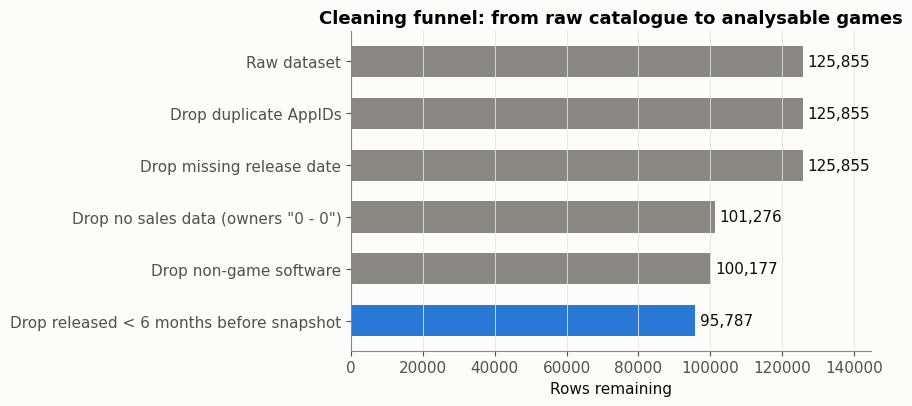

In [17]:
# Figure 1: Row funnel
fig, ax = plt.subplots(figsize=(9, 4.2))
f = funnel_df.iloc[::-1]
bars = ax.barh(f["step"], f["rows_remaining"], color=[AFTER if i == 0 else BEFORE for i in range(len(f))], height=0.6)
for b, v in zip(bars, f["rows_remaining"]):
    ax.text(v + funnel_df["rows_remaining"].max() * 0.01, b.get_y() + b.get_height() / 2, f"{v:,}", va="center", color=INK)
ax.set_xlabel("Rows remaining"); ax.grid(axis="y", visible=False)
ax.set_title("Cleaning funnel: from raw catalogue to analysable games")
ax.set_xlim(0, funnel_df["rows_remaining"].max() * 1.15)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/01_row_funnel.png", dpi=200); plt.show()

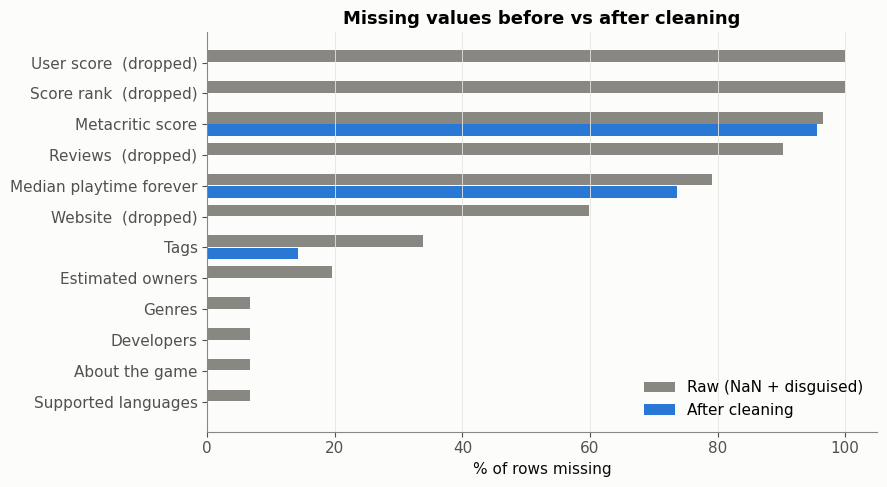

Note: remaining missing Metacritic/playtime values are real 'not reviewed / not tracked' — kept as NaN on purpose.


In [18]:
# Figure 2: Missing values before vs after (columns that still exist, or were replaced by a cleaner version)
compare_map = {  # raw column -> cleaned equivalent
    "Metacritic score": "metacritic_score", "Median playtime forever": "Median playtime forever",
    "Tags": "tags", "Supported languages": "languages", "Genres": "genres",
    "Developers": "developers", "About the game": "About the game", "Estimated owners": "owners_high",
    "Score rank": None, "Reviews": None, "Website": None, "User score": None,
}
before = miss_before.loc[list(compare_map), "total_missing_%"]
def pct_missing_after(c):
    if c is None: return 0.0  # column dropped (replaced by a flag or removed)
    s = df[c]
    if s.apply(lambda v: isinstance(v, list)).any(): return s.str.len().eq(0).mean() * 100
    if s.dtype == object or pd.api.types.is_string_dtype(s): return (s.isna() | s.astype(str).str.strip().eq("")).mean() * 100
    return (s.isna() | s.eq(0) if c == "owners_high" else s.isna()).mean() * 100
after = pd.Series({k: pct_missing_after(v) for k, v in compare_map.items()})
order = before.sort_values().index
y = np.arange(len(order))
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(y + 0.2, before[order], height=0.38, color=BEFORE, label="Raw (NaN + disguised)")
ax.barh(y - 0.2, after[order], height=0.38, color=AFTER, label="After cleaning")
ax.set_yticks(y, [f"{c}{'  (dropped)' if compare_map[c] is None else ''}" for c in order])
ax.set_xlabel("% of rows missing"); ax.set_xlim(0, 105); ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", frameon=False)
ax.set_title("Missing values before vs after cleaning")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/02_missing_before_after.png", dpi=200); plt.show()
print("Note: remaining missing Metacritic/playtime values are real 'not reviewed / not tracked' — kept as NaN on purpose.")

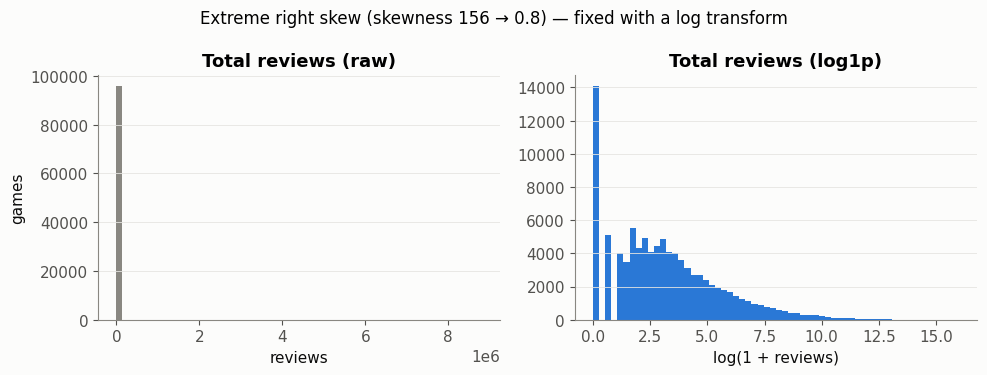

In [19]:
# Figure 3: Skew before vs after log transform
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].hist(df["total_reviews"], bins=60, color=BEFORE)
axes[0].set_title("Total reviews (raw)"); axes[0].set_xlabel("reviews"); axes[0].set_ylabel("games")
axes[1].hist(df["log_total_reviews"], bins=60, color=AFTER)
axes[1].set_title("Total reviews (log1p)"); axes[1].set_xlabel("log(1 + reviews)")
for a in axes: a.grid(axis="x", visible=False)
fig.suptitle(f"Extreme right skew (skewness {df['total_reviews'].skew():.0f} → {df['log_total_reviews'].skew():.1f}) — fixed with a log transform", fontsize=12)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/03_log_transform.png", dpi=200); plt.show()

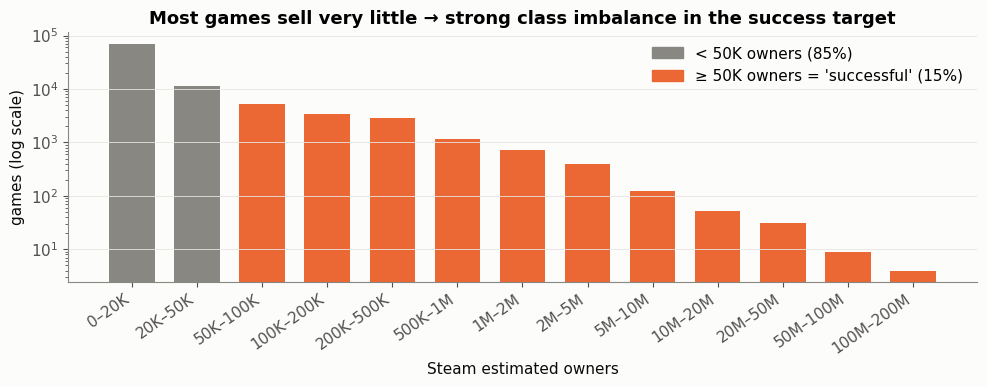

In [20]:
# Figure 4: Owners distribution + target class balance
own_counts = df.groupby(["owners_low", "owners_high"]).size().reset_index(name="games").sort_values("owners_low")
def fmt(n): return f"{n/1e6:g}M" if n >= 1e6 else f"{n/1e3:g}K" if n >= 1e3 else str(int(n))
own_counts["label"] = own_counts.apply(lambda r: f"{fmt(r.owners_low)}–{fmt(r.owners_high)}", axis=1)
fig, ax = plt.subplots(figsize=(10, 4))
colors = [ACCENT if lo >= 50_000 else BEFORE for lo in own_counts["owners_low"]]
ax.bar(own_counts["label"], own_counts["games"], color=colors, width=0.7)
ax.set_yscale("log"); ax.set_ylabel("games (log scale)"); ax.set_xlabel("Steam estimated owners")
ax.grid(axis="x", visible=False); plt.xticks(rotation=35, ha="right")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BEFORE, label=f"< 50K owners ({(1-df.success_50k.mean())*100:.0f}%)"),
                   Patch(color=ACCENT, label=f"≥ 50K owners = 'successful' ({df.success_50k.mean()*100:.0f}%)")], frameon=False)
ax.set_title("Most games sell very little → strong class imbalance in the success target")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/04_owners_class_balance.png", dpi=200); plt.show()

## Step 9 — Export for the team
| File | For | Contents |
|---|---|---|
| `steam_clean.csv` | Rachel (EDA), Calvin (Tableau) | One row per game, readable columns, lists as comma-separated text, no long descriptions |
| `steam_model.parquet` | Chinmayi (ML) | Numeric/boolean pre-release features + outcomes + targets |
| `steam_genres_long.csv`, `steam_tags_long.csv` | Calvin (Tableau) | One row per (game, genre/tag) — lets Tableau filter by genre/tag properly |
| `data_dictionary.csv` | Everyone | Every column, its type and whether it's a **pre-release feature** or **post-release outcome** |
| `cleaning_funnel.csv`, `figures/` | Slides & report | Row funnel numbers and the 4 cleaning charts |

These files are too big for GitHub's 100 MB limit in some cases. Everyone can run this notebook and download the files. Ask Keerat if you need help.

In [21]:
OUTCOME_COLS = ["owners_low", "owners_high", "owners_mid", "log_owners_low", "log_owners_high",
                "Positive", "Negative", "total_reviews", "positive_ratio", "log_total_reviews", "log_positive",
                "log_negative", "Peak CCU", "log_peak_ccu", "Recommendations", "log_recommendations",
                "Average playtime forever", "Average playtime two weeks", "Median playtime forever",
                "Median playtime two weeks", "metacritic_score", "Metacritic score", "Discount", "DLC count"]
TARGET_COLS = ["success_50k", "success_reviews"]
BASE_PRE = ["Price", "price_capped", "log_price", "price_outlier", "is_free", "Required age", "is_mature",
                "Windows", "Mac", "Linux", "n_platforms", "n_languages", "n_audio_languages", "supports_english",
                "Achievements", "achievements_capped", "achievements_outlier", "about_word_count",
                "release_year", "release_month", "release_dayofweek", "is_early_access", "self_published",
                "publisher_n_games", "n_genres", "n_categories", "has_website", "has_support_url",
                "has_support_email", "has_press_quotes", "has_content_notes"]
PRE_RELEASE = BASE_PRE + list(G.columns) + list(C.columns)
ID_COLS = ["AppID", "Name", "release_date", "developer", "publisher"]

# 1) Model file
model_df = df[ID_COLS + PRE_RELEASE + OUTCOME_COLS + TARGET_COLS].copy()
bool_cols = model_df.select_dtypes(bool).columns
model_df[bool_cols] = model_df[bool_cols].astype(int)
try:
    model_df.to_parquet(f"{OUT_DIR}/steam_model.parquet", index=False)
except Exception as e:  # no pyarrow -> csv fallback
    print("parquet failed, writing csv:", e); model_df.to_csv(f"{OUT_DIR}/steam_model.csv", index=False)

# 2) Readable clean file (EDA + Tableau)
clean = df[ID_COLS + BASE_PRE + OUTCOME_COLS + TARGET_COLS].copy()
for c in ["genres", "categories", "tags", "languages"]:
    clean[c] = df[c].apply(", ".join)
clean["owners_range"] = df.apply(lambda r: f"{fmt(r.owners_low)}–{fmt(r.owners_high)}", axis=1)
clean.to_csv(f"{OUT_DIR}/steam_clean.csv", index=False)

# 3) Long tables for Tableau
df[["AppID", "genres"]].explode("genres").dropna().rename(columns={"genres": "genre"}).to_csv(f"{OUT_DIR}/steam_genres_long.csv", index=False)
df[["AppID", "tags"]].explode("tags").dropna().rename(columns={"tags": "tag"}).to_csv(f"{OUT_DIR}/steam_tags_long.csv", index=False)

# 4) Data dictionary + funnel
role = {**{c: "id" for c in ID_COLS}, **{c: "pre-release feature" for c in PRE_RELEASE},
        **{c: "post-release outcome (do NOT use as model input)" for c in OUTCOME_COLS},
        **{c: "candidate target" for c in TARGET_COLS}}
pd.DataFrame({"column": model_df.columns, "dtype": model_df.dtypes.astype(str).values,
              "role": [role[c] for c in model_df.columns],
              "missing_%": (model_df.isna().mean() * 100).round(1).values}).to_csv(f"{OUT_DIR}/data_dictionary.csv", index=False)
funnel_df.to_csv(f"{OUT_DIR}/cleaning_funnel.csv", index=False)

for fn in sorted(os.listdir(OUT_DIR)):
    p = os.path.join(OUT_DIR, fn)
    if os.path.isfile(p): print(f"{fn:<28} {os.path.getsize(p)/1e6:7.1f} MB")

cleaning_funnel.csv              0.0 MB
data_dictionary.csv              0.0 MB
steam_clean.csv                 63.0 MB
steam_genres_long.csv            4.2 MB
steam_model.parquet              8.3 MB
steam_tags_long.csv             20.8 MB


## Summary numbers for the slide
The EDA and ML sections need this as well.

In [22]:
print(f"Raw:     {funnel_df.rows_remaining.iloc[0]:,} rows × {raw.shape[1]} columns (after header fix)")
print(f"Clean:   {len(df):,} games ({len(df)/funnel_df.rows_remaining.iloc[0]*100:.0f}% kept)")
print(f"Model:   {len(PRE_RELEASE)} pre-release features, {len(OUTCOME_COLS)} outcome columns, {len(TARGET_COLS)} candidate targets")
print(f"Snapshot date: {SNAPSHOT_DATE.date()}  |  release years {df.release_year.min()}–{df.release_year.max()}")
for t in TARGET_COLS:
    print(f"{t}: {df[t].mean()*100:.1f}% positive  → imbalanced (consider class weights / SMOTE / PR-AUC)")
print("\nRows removed per step:")
print(funnel_df.assign(removed=-funnel_df.rows_remaining.diff()).fillna(0).astype({"removed": int}).to_string(index=False))

Raw:     125,855 rows × 40 columns (after header fix)
Clean:   95,787 games (76% kept)
Model:   72 pre-release features, 24 outcome columns, 2 candidate targets
Snapshot date: 2026-03-01  |  release years 1997–2025
success_50k: 14.6% positive  → imbalanced (consider class weights / SMOTE / PR-AUC)
success_reviews: 10.8% positive  → imbalanced (consider class weights / SMOTE / PR-AUC)

Rows removed per step:
                                    step  rows_remaining  removed
                             Raw dataset          125855        0
                   Drop duplicate AppIDs          125855        0
               Drop missing release date          125855        0
     Drop no sales data (owners "0 - 0")          101276    24579
                  Drop non-game software          100177     1099
Drop released < 6 months before snapshot           95787     4390
